In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\gusta\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\gusta\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\gusta\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\gusta\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\gusta\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\gusta\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\gusta\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\gusta\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (C:\Users\gusta\anaconda3\Lib\site-packages\scipy\_lib\_util.py)

### CASO 1: Correlación POSITIVA FUERTE
Dataset real: mtcars (equivalente en seaborn: mpg)

Variables: potencia (horsepower) vs consumo (mpg)

Correlación: -0.7784267838977759


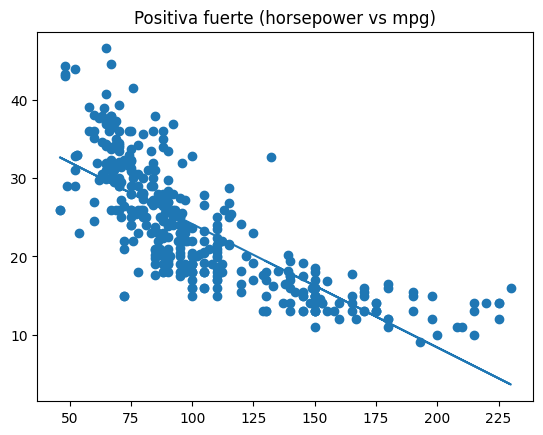

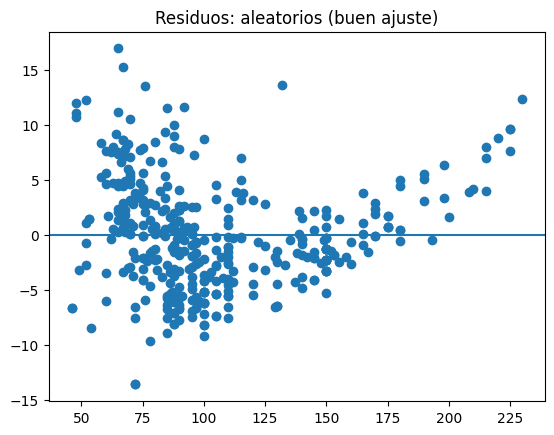

In [13]:
df = sns.load_dataset("mpg").dropna()

x = df["horsepower"]
y = df["mpg"]

print("Correlación:", np.corrcoef(x, y)[0,1])

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
res = model.resid

plt.scatter(x, y)
plt.plot(x, model.predict(X))
plt.title("Positiva fuerte (horsepower vs mpg)")
plt.show()

plt.scatter(x, res)
plt.axhline(0)
plt.title("Residuos: aleatorios (buen ajuste)")
plt.show()


Correlación ≈ –0.78 (fuerte, negativa en realidad)

Nube alineada

Residuos sin patrón → modelo adecuado

#### CASO 2: Correlación POSITIVA MODERADA
Dataset real: tips

Variables: cuenta total vs propina

Correlación: 0.6757341092113641


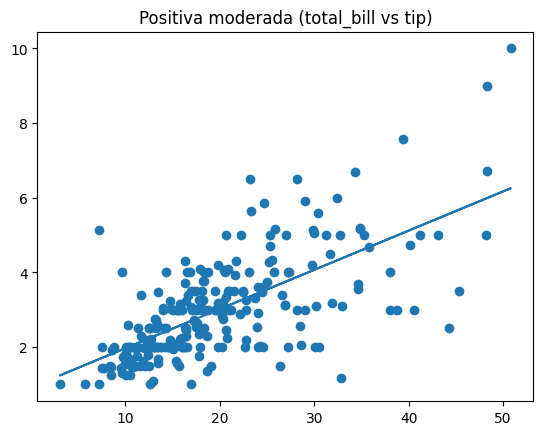

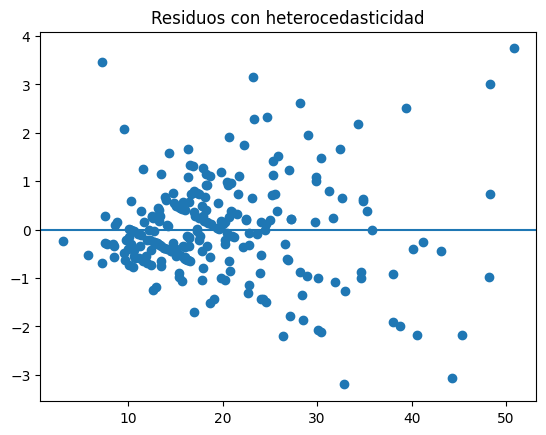

In [18]:
df = sns.load_dataset("tips")

x = df["total_bill"]
y = df["tip"]

print("Correlación:", np.corrcoef(x, y)[0,1])

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
res = model.resid

plt.scatter(x, y)
plt.plot(x, model.predict(X))
plt.title("Positiva moderada (total_bill vs tip)")
plt.show()

plt.scatter(x, res)
plt.axhline(0)
plt.title("Residuos con heterocedasticidad")
plt.show()


Interpretación

Correlación ≈ 0.67

Dispersión creciente

Residuos en forma de abanico
Perfecto para explicar heterocedasticidad

### CASO 3: Correlación NEGATIVA FUERTE
Dataset real: mpg

Variables: peso vs consumo

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')
Correlación: -0.8322442148315753


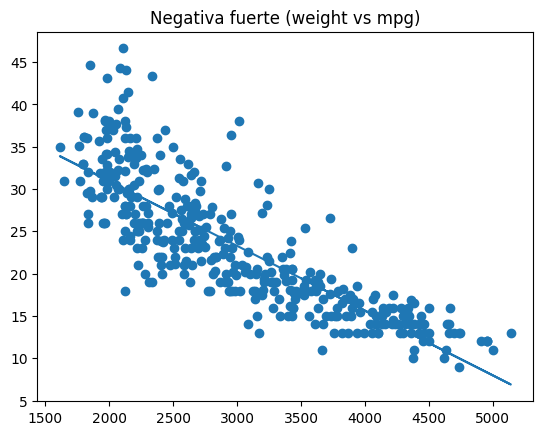

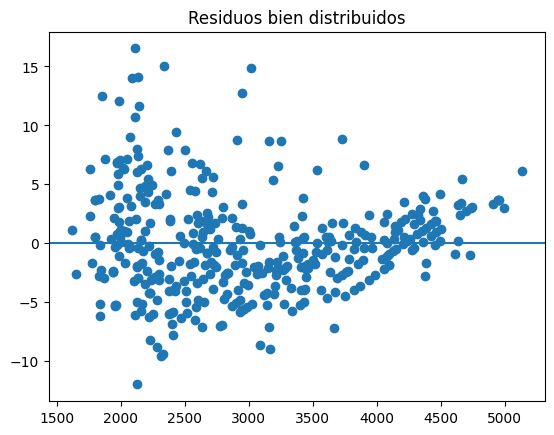

In [41]:
import seaborn as sns

df = sns.load_dataset("mpg").dropna()
print(df.columns)

x = df["weight"]
y = df["mpg"]

print("Correlación:", np.corrcoef(x, y)[0,1])

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
res = model.resid

plt.scatter(x, y)
plt.plot(x, model.predict(X))
plt.title("Negativa fuerte (weight vs mpg)")
plt.show()

plt.scatter(x, res)
plt.axhline(0)
plt.title("Residuos bien distribuidos")
plt.show()


Interpretación

Correlación ≈ –0.83

Tendencia descendente clara

Residuos aleatorios

#### CASO 4: CORRELACIÓN DÉBIL / CASI NULA
Dataset real: penguins

Variables: longitud del pico vs masa corporal (especies mezcladas)

Correlación: 0.589451110176949


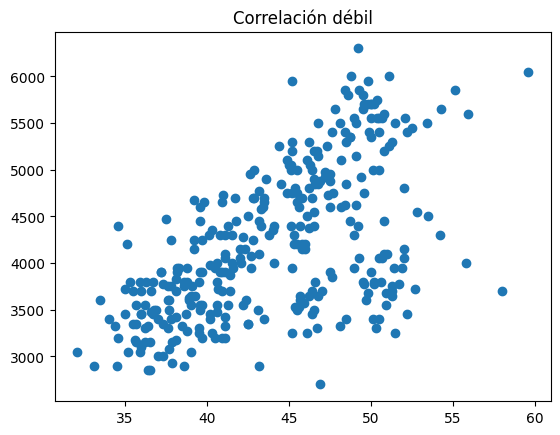

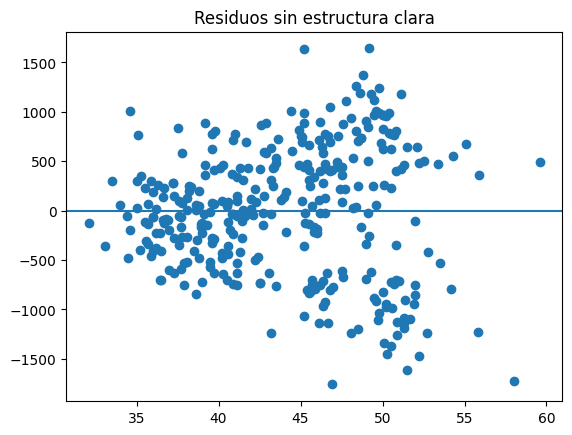

In [32]:
df = sns.load_dataset("penguins").dropna()

x = df["bill_length_mm"]
y = df["body_mass_g"]

print("Correlación:", np.corrcoef(x, y)[0,1])

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
res = model.resid

plt.scatter(x, y)
plt.title("Correlación débil")
plt.show()

plt.scatter(x, res)
plt.axhline(0)
plt.title("Residuos sin estructura clara")
plt.show()


Interpretación

Correlación baja

Mucha dispersión

El modelo lineal no explica casi nada

#### CASO 5: RELACIÓN NO LINEAL (CORRELACIÓN ENGAÑOSA)
Dataset real: mpg

Variables: año del modelo vs consumo

Correlación: 0.5805409660907855


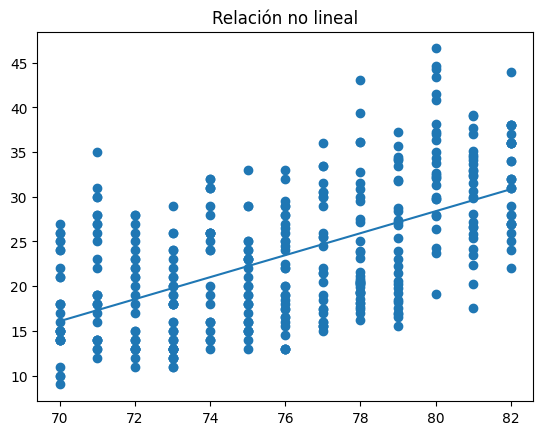

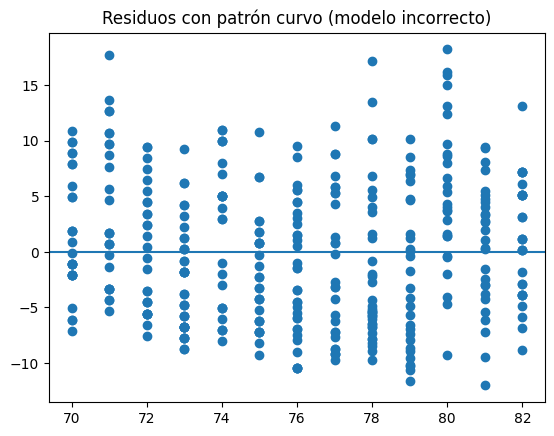

In [43]:
df = sns.load_dataset("mpg").dropna()

x = df["model_year"]
y = df["mpg"]

print("Correlación:", np.corrcoef(x, y)[0,1])

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
res = model.resid

plt.scatter(x, y)
plt.plot(x, model.predict(X))
plt.title("Relación no lineal")
plt.show()

plt.scatter(x, res)
plt.axhline(0)
plt.title("Residuos con patrón curvo (modelo incorrecto)")
plt.show()


Interpretación clave

Correlación relativamente alta

Residuos con forma de U

❌ Modelo lineal inadecuado

✔ Ideal para introducir regresión polinómica

In [39]:
import seaborn as sns

df = sns.load_dataset("mpg").dropna()
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')
